In [5]:
import pydynverse as pdv

logger = pdv.logger
logger.setLevel("DEBUG")

pdv.settings.backend = "python_function"

In [6]:
# 1. 准备数据(wrap)
dataset = pdv.data.load_simulation_data(data_filename="real/silver/fibroblast-reprogramming_treutlein.rds")
dataset

{'id': 'real/silver/fibroblast-reprogramming_treutlein',
 'cell_ids': ['1_iN1_C01',
  '1_iN1_C02',
  '1_iN1_C03',
  '1_iN1_C04',
  '1_iN1_C05',
  '1_iN1_C07',
  '1_iN1_C08',
  '1_iN1_C09',
  '1_iN1_C10',
  '1_iN1_C11',
  '1_iN1_C12',
  '1_iN1_C13',
  '1_iN1_C14',
  '1_iN1_C15',
  '1_iN1_C16',
  '1_iN1_C17',
  '1_iN1_C19',
  '1_iN1_C20',
  '1_iN1_C21',
  '1_iN1_C22',
  '1_iN1_C23',
  '1_iN1_C25',
  '1_iN1_C26',
  '1_iN1_C27',
  '1_iN1_C29',
  '1_iN1_C30',
  '1_iN1_C31',
  '1_iN1_C33',
  '1_iN1_C34',
  '1_iN1_C35',
  '1_iN1_C36',
  '1_iN1_C37',
  '1_iN1_C38',
  '1_iN1_C40',
  '1_iN1_C41',
  '1_iN1_C42',
  '1_iN1_C43',
  '1_iN1_C44',
  '1_iN1_C46',
  '1_iN1_C47',
  '1_iN1_C48',
  '1_iN1_C49',
  '1_iN1_C51',
  '1_iN1_C52',
  '1_iN1_C53',
  '1_iN1_C54',
  '1_iN1_C55',
  '1_iN1_C56',
  '1_iN1_C57',
  '1_iN1_C58',
  '1_iN1_C60',
  '1_iN1_C61',
  '1_iN1_C62',
  '1_iN1_C64',
  '1_iN1_C66',
  '1_iN1_C67',
  '1_iN1_C68',
  '1_iN1_C69',
  '1_iN1_C70',
  '1_iN1_C71',
  '1_iN1_C72',
  '1_iN1_C73',
 

In [7]:
# 2. 选择方法(method)
methods_selected = pdv.methods.ti_cluster_mst()
logger.info(f"Methods {methods_selected} selecting finished")

[2025年02月21日 15时31分17秒] INFO     backend: python_function                                                    
                        INFO     Methods {'method': {'id': 'cluster_mst', 'name': 'Cluster_MST', 'source': 'xxx',  
                                 'platform': 'Python'}, 'wrapper': {'type': 'cluster_graph', 'topology_inference': 
                                 'free', 'trajectory_types': ['linear', 'bifurcation', 'convergence',              
                                 'multifurcation', 'tree'], 'input_required': ['counts'], 'input_optional':        
                                 ['groups_id'], 'inputs':     input_id  required               type                
                                 0     counts      True         expression                                         
                                 1  groups_id     False  prior_information                                         
                                 2     dimred     False          parameter    

In [15]:
dataset.keys()

dict_keys(['id', 'cell_ids', 'cell_info', 'source', 'normalisation_info', 'creation_date', 'group_ids', 'grouping', 'milestone_ids', 'milestone_network', 'divergence_regions', 'milestone_percentages', 'progressions', 'trajectory_type', 'directed', 'counts', 'expression', 'feature_info', 'prior_information', 'waypoint_cells', 'root_milestone_id', 'feature_ids', 'adata'])

In [16]:
dataset["group_ids"]

['d2_induced',
 'd2_intermediate',
 'MEF',
 'd5_intermediate',
 'd5_earlyiN',
 'Neuron',
 'Myocyte']

In [17]:
# 3. 运行方法(wrap)
dataset = pdv.wrap.add_prior_information(dataset, groups_id=dataset["grouping"]) # 添加先验知识
model = pdv.wrap.infer_trajectory(dataset, methods_selected) # 此处尝试修改参数
logger.info(f"Methods executing finished, model: {model}")

[2025年02月21日 15时32分56秒] DEBUG    Temp wd: /tmp/tmpicnrunkv                                                   
                        DEBUG    ti_paga_function executing                                                        
                        DEBUG    priors: {'groups_id': ['d2_induced', 'd2_induced', 'd2_induced',                  
                                 'd2_intermediate', 'd2_intermediate', 'd2_induced', 'd2_intermediate',            
                                 'd2_induced', 'd2_induced', 'd2_intermediate', 'd2_induced', 'd2_induced',        
                                 'd2_induced', 'd2_induced', 'd2_intermediate', 'd2_induced', 'd2_intermediate',   
                                 'd2_induced', 'd2_intermediate', 'd2_induced', 'd2_induced', 'MEF', 'd2_induced', 
                                 'MEF', 'MEF', 'd2_intermediate', 'd2_induced', 'd2_induced', 'd2_induced',        
                                 'd2_intermediate', 'd2_induced', 'd2_induced'

[2025年02月21日 15时33分00秒] INFO     Coloring by grouping                                                        
                        DEBUG    selecting waypoints                                                               
[2025年02月21日 15时33分01秒] DEBUG    selecting waypoints shape is (209, 355), finished!                          
                        INFO     Result plotting finished                                                          


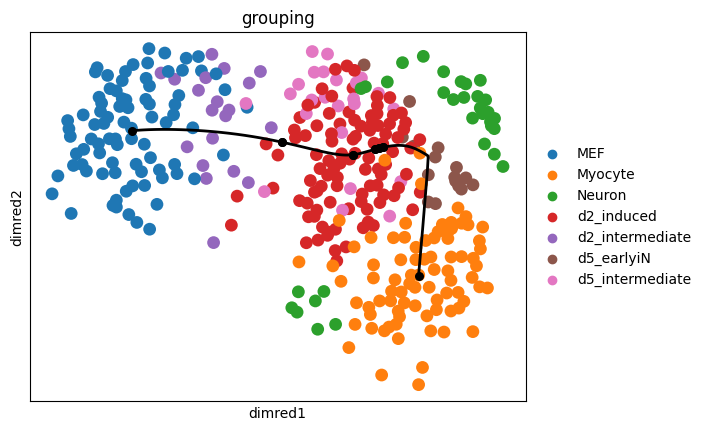

In [18]:
# 4. 绘制轨迹(dimred+plot)
cluster_list = dataset["grouping"]
model = pdv.wrap.add_dimred(model, pdv.dimred.dimred_mds, expression_source=dataset["expression"])  # 提取降维结果
pdv.plot.plot_dimred(model, grouping=cluster_list)
logger.info("Result plotting finished")